In [74]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

In [75]:
df = pd.read_excel("Online Retail.xlsx")

KeyboardInterrupt: 

In [ ]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [ ]:
df.shape

(541909, 8)

In [ ]:
df.columns

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country'],
      dtype='object')

In [ ]:
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [ ]:
df = df.dropna()

In [ ]:
X = df[["Quantity", "UnitPrice"]]

In [ ]:
imputer = SimpleImputer(strategy='mean')
X = imputer.fit_transform(X)

In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [ ]:
wcss = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

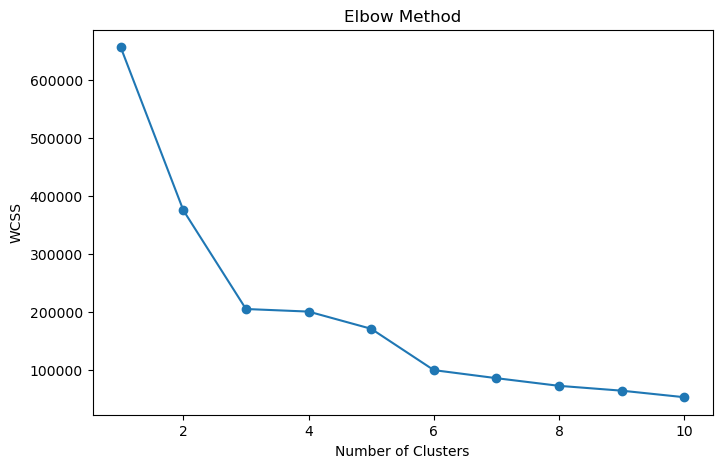

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(range(1,11), wcss, marker='o')
plt.title('Elbow Method')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.show()

In [ ]:
kmeans = KMeans(n_clusters=3, init='k-means++', random_state=42)

clusters = kmeans.fit_predict(X_scaled)

In [ ]:
df['Cluster'] = clusters

In [ ]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Cluster
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,1
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,1
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,1
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,1
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,1


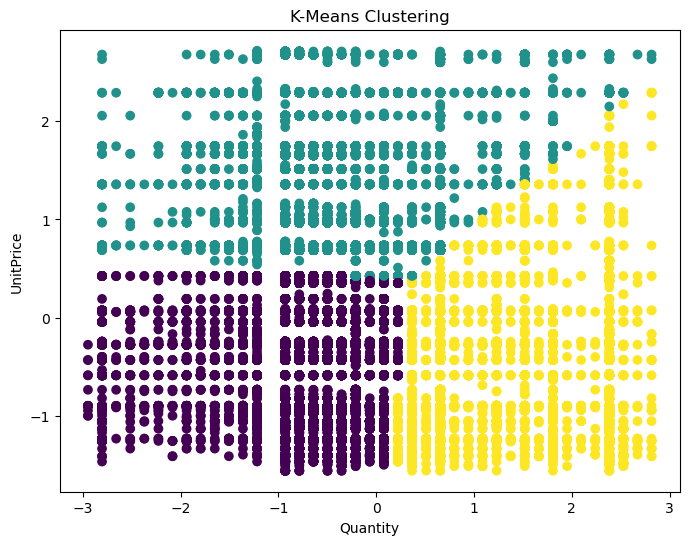

In [ ]:
plt.figure(figsize=(8,6))

plt.scatter(X_scaled[:,0], X_scaled[:,1], c=clusters, cmap='viridis')

plt.xlabel('Quantity')
plt.ylabel('UnitPrice')
plt.title('K-Means Clustering')

plt.show()

In [ ]:
Q1 = df[['Quantity','UnitPrice']].quantile(0.25)
Q3 = df[['Quantity','UnitPrice']].quantile(0.75)

IQR = Q3 - Q1

df = df[~((df[['Quantity','UnitPrice']] < (Q1 - 1.5 * IQR)) |
          (df[['Quantity','UnitPrice']] > (Q3 + 1.5 * IQR))).any(axis=1)]

In [ ]:
print(kmeans.cluster_centers_)

[[-0.65967788 -0.45026281]
 [-0.48181755  1.36819106]
 [ 1.12357296 -0.59381741]]


In [ ]:
print(kmeans.inertia_)

205239.84389964162


In [77]:
from sklearn.metrics import silhouette_score

sample_X = X_scaled[:10000]
sample_clusters = clusters[:10000]

score = silhouette_score(sample_X, sample_clusters)

print(score)

0.4851000335173536
